# Road Type Classifier (autoroute / urbaine / rurale)
Trained on A2D2 instance-org Kaggle mirror, labeled by sequence (not per-frame). Off-road and damage are separate models, not part of this notebook.

## 1. Setup & imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
import shutil

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Config

In [2]:
RAW_IMAGE_DIR = "/kaggle/input/datasets/testseries1/a2d2-instance-org/a2d2_instace_org/images/train"
LABELED_DIR = "/kaggle/working/labeled"

CLASS_NAMES = ["autoroute", "urbaine", "rurale"]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE_TUNE = 5
FRAME_STEP = 10  # keep every 10th frame per sequence, avoid near-duplicates


## 3. Sequence labels
Manually assigned by eyeballing 4-frame previews per sequence. 3 mixed-scene sequences dropped entirely (documented below).

In [3]:
SEQUENCE_LABELS = {
    # --- urbaine (11) ---
    "20180807145028": "urbaine",
    "20180810142822": "urbaine",
    "20180925101535": "urbaine",
    "20180925112730": "urbaine",
    "20180925124435": "urbaine",
    "20180925135056": "urbaine",
    "20181008095521": "urbaine",
    "20181016095036": "urbaine",
    "20181107132730": "urbaine",
    "20181107133258": "urbaine",
    "20181204191844": "urbaine",

    # --- rurale (4) ---
    "20181107132300": "rurale",
    "20181108103155": "rurale",
    "20181204154421": "rurale",
    "20181204170238": "rurale",

    # --- autoroute (5) ---
    "20181108084007": "autoroute",
    "20181108091945": "autoroute",
    "20181108123750": "autoroute",
    "20181108141609": "autoroute",
    "20181204135952": "autoroute",
}

FRAME_STEP_OVERRIDES = {
    "20181107132300": 4,
    "20181108103155": 4,
    "20181204154421": 4,
    "20181204170238": 4,
}
# Dropped intentionally — mixed scene types within a single recording:
#   20181016082154, 20181016125231, 20181107133445
# Revisit only if rurale performs poorly after the first training pass.

print(f"{len(SEQUENCE_LABELS)} sequences labeled")
for cls in CLASS_NAMES:
    count = sum(1 for v in SEQUENCE_LABELS.values() if v == cls)
    print(f"  {cls}: {count} sequences")


20 sequences labeled
  autoroute: 5 sequences
  urbaine: 11 sequences
  rurale: 4 sequences


## 4. Sanity-check a few sequences before copying anything
Quick visual re-check — catch a mislabeled sequence now, not after training.

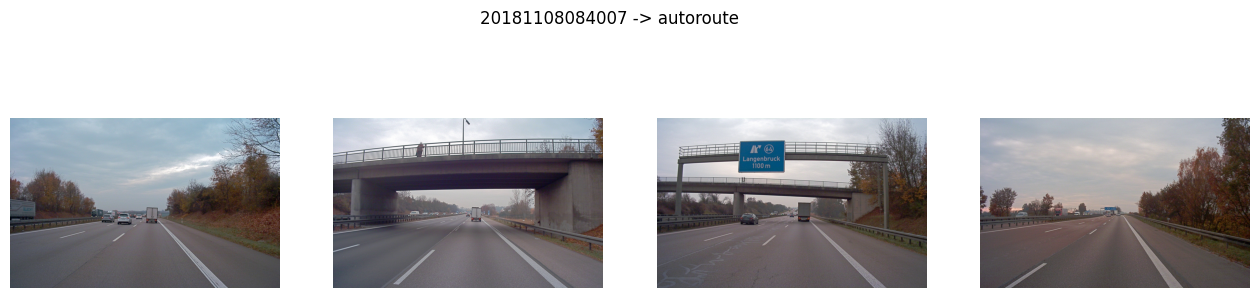

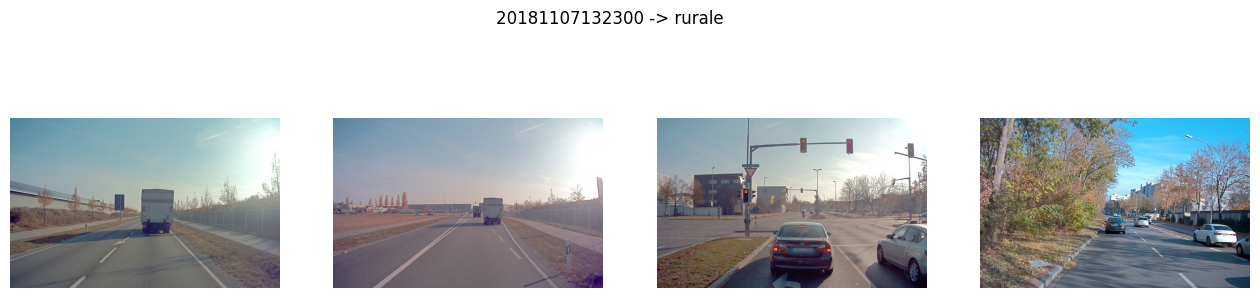

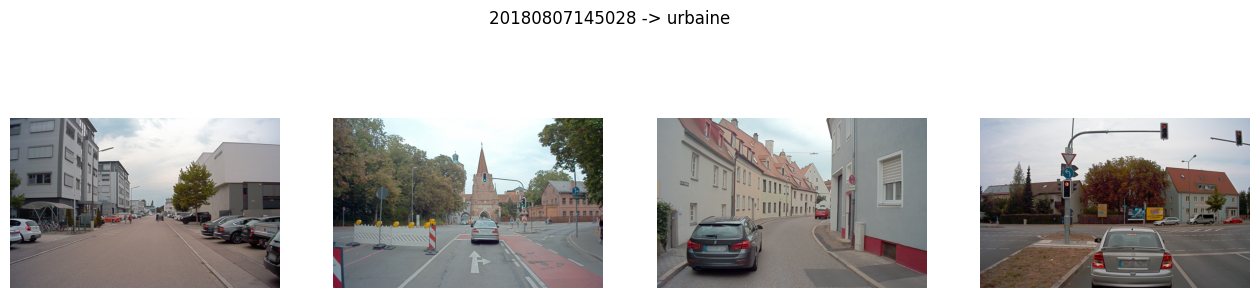

In [4]:
def preview_sequence(seq_name, count=4):
    files = sorted([f for f in os.listdir(RAW_IMAGE_DIR) if f.startswith(seq_name)])
    if not files:
        print(f"No files found for {seq_name}")
        return
    step = max(1, len(files) // count)
    fig, axes = plt.subplots(1, count, figsize=(16, 4))
    for i in range(count):
        idx = min(i * step, len(files) - 1)
        img = Image.open(os.path.join(RAW_IMAGE_DIR, files[idx]))
        axes[i].imshow(img)
        axes[i].axis("off")
    fig.suptitle(f"{seq_name} -> {SEQUENCE_LABELS.get(seq_name, '?')}")
    plt.show()

# Spot-check a couple, adjust list as you like
for seq in ["20181108084007", "20181107132300", "20180807145028"]:
    preview_sequence(seq)


## 5. Build the labeled dataset folders
Copies every Nth frame from each labeled sequence into `/kaggle/working/labeled/<class>/` — the layout training expects.

In [5]:
def build_labeled_folders():
    if os.path.exists(LABELED_DIR):
        shutil.rmtree(LABELED_DIR)  # clean slate if re-running

    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(LABELED_DIR, cls), exist_ok=True)

    all_files = sorted(os.listdir(RAW_IMAGE_DIR))
    copied_counts = {cls: 0 for cls in CLASS_NAMES}

    for seq_name, road_type in SEQUENCE_LABELS.items():
        step = FRAME_STEP_OVERRIDES.get(seq_name, FRAME_STEP)
        seq_files = [f for f in all_files if f.startswith(seq_name)]
        for f in seq_files[::step]:
            src = os.path.join(RAW_IMAGE_DIR, f)
            dst = os.path.join(LABELED_DIR, road_type, f)
            shutil.copy(src, dst)
            copied_counts[road_type] += 1

    print("Images copied per class:")
    for cls, count in copied_counts.items():
        print(f"  {cls}: {count}")

build_labeled_folders()

Images copied per class:
  autoroute: 726
  urbaine: 954
  rurale: 638


In [6]:
import os, shutil

extra_rural_dir = "/kaggle/input/datasets/khawlaelhamdi/rural-roads"

added = 0
for root, dirs, files in os.walk(extra_rural_dir):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            src = os.path.join(root, f)
            dst = os.path.join(LABELED_DIR, "rurale", f"visao_{f}")  # prefix avoids filename clashes with A2D2 files
            shutil.copy(src, dst)
            added += 1

print(f"Added {added} extra rural images from the visao dataset")

Added 105 extra rural images from the visao dataset


In [7]:
import os

image_dir = "/kaggle/input/datasets/testseries1/a2d2-instance-org/a2d2_instace_org/images/train"
all_files = sorted(os.listdir(image_dir))

sequence_counts = {}
for seq_name in SEQUENCE_LABELS.keys():
    count = sum(1 for f in all_files if f.startswith(seq_name))
    sampled = len(range(0, count, FRAME_STEP))  # what you'd actually get after every-10th sampling
    sequence_counts[seq_name] = (count, sampled)

print(f"{'Sequence':<16} {'Total frames':<14} {'After /10 sampling':<20} {'Class'}")
total_all = 0
total_sampled = 0
for seq, (total, sampled) in sequence_counts.items():
    cls = SEQUENCE_LABELS[seq]
    print(f"{seq:<16} {total:<14} {sampled:<20} {cls}")
    total_all += total
    total_sampled += sampled

print(f"\nTotal raw frames across labeled sequences: {total_all}")
print(f"Total images after keeping every {FRAME_STEP}th frame: {total_sampled}")

print("\nPer class after sampling:")
for cls in CLASS_NAMES:
    cls_total = sum(sampled for seq, (total, sampled) in sequence_counts.items() if SEQUENCE_LABELS[seq] == cls)
    print(f"  {cls}: {cls_total}")

Sequence         Total frames   After /10 sampling   Class
20180807145028   840            84                   urbaine
20180810142822   852            86                   urbaine
20180925101535   985            99                   urbaine
20180925112730   880            88                   urbaine
20180925124435   929            93                   urbaine
20180925135056   865            87                   urbaine
20181008095521   774            78                   urbaine
20181016095036   807            81                   urbaine
20181107132730   873            88                   urbaine
20181107133258   167            17                   urbaine
20181204191844   1525           153                  urbaine
20181107132300   531            54                   rurale
20181108103155   1008           101                  rurale
20181204154421   693            70                   rurale
20181204170238   316            32                   rurale
20181108084007   1277         

## 6. Load the dataset for training

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    LABELED_DIR,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASS_NAMES,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    LABELED_DIR,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASS_NAMES,
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print("Class order:", train_ds.class_names)


Found 2423 files belonging to 3 classes.
Using 1697 files for training.


I0000 00:00:1784283617.384029      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784283617.386804      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2423 files belonging to 3 classes.
Using 726 files for validation.
Class order: ['autoroute', 'urbaine', 'rurale']


## 7. Sanity check — look at labeled images before trusting anything

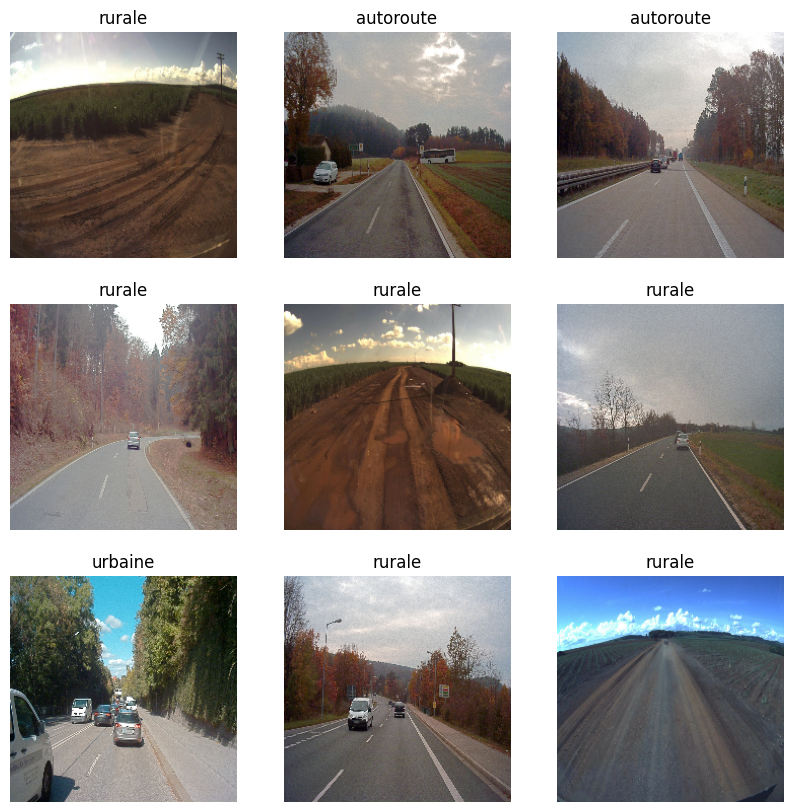

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis("off")
plt.show()


## 8. Data augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
])


## 9. Build the model — transfer learning on MobileNetV2

In [11]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # frozen for phase 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Compile & train (phase 1 — frozen base)

In [12]:
print(train_ds.class_names)  # confirm index order before trusting class_weight below

class_weight = {0: 1.0, 1: 1.0, 2: 2.5}  # update indices to match the printed order above

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop],
    class_weight=class_weight,
)

['autoroute', 'urbaine', 'rurale']
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - accuracy: 0.5716 - loss: 1.2008 - val_accuracy: 0.7567 - val_loss: 0.6122
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step - accuracy: 0.7142 - loss: 0.8755 - val_accuracy: 0.8209 - val_loss: 0.4761
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 259ms/step - accuracy: 0.7955 - loss: 0.6816 - val_accuracy: 0.8155 - val_loss: 0.4705
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - accuracy: 0.8032 - loss: 0.6300 - val_accuracy: 0.8102 - val_loss: 0.4711
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.8279 - loss: 0.5699 - val_accuracy: 0.8556 - val_loss: 0.4001
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.8309 - loss: 0.5879 - val_accuracy: 0.8610 - val_loss: 0.3812
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - accuracy: 0.8539 - loss: 0.5379 - val_accuracy: 0.8636 - val_loss: 0.3904
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accurac

## 11. Plot training curves

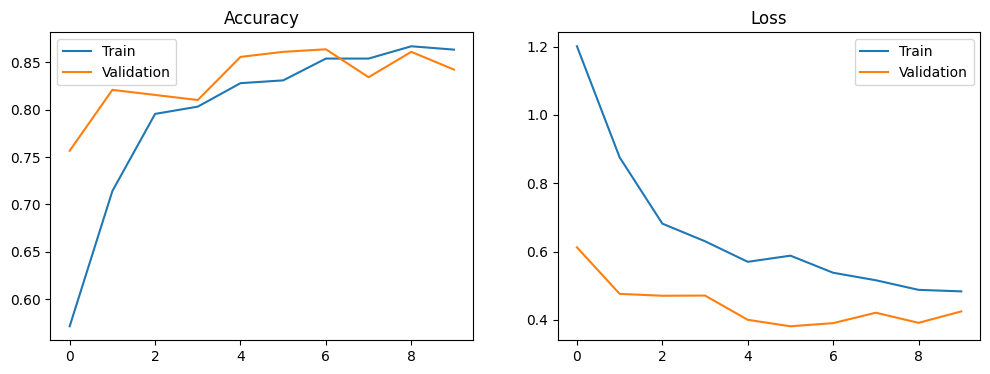

In [13]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train")
plt.plot(epochs_range, val_acc, label="Validation")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train")
plt.plot(epochs_range, val_loss, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()


## 12. Optional phase 2 — fine-tune
Only run this if phase 1 accuracy isn't good enough — small dataset, easy to overfit here.

In [14]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=[early_stop],
)


Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.7242 - loss: 0.7066 - val_accuracy: 0.8021 - val_loss: 0.4489
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - accuracy: 0.8356 - loss: 0.4435 - val_accuracy: 0.8182 - val_loss: 0.4327
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step - accuracy: 0.8550 - loss: 0.3956 - val_accuracy: 0.8075 - val_loss: 0.4760


## 13. Evaluate on test set + per-class breakdown
Check rurale specifically — it has the fewest sequences, most likely to underperform.

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.8267 - loss: 0.4239
              precision    recall  f1-score   support

   autoroute       0.68      0.94      0.79        85
     urbaine       0.89      0.92      0.91       155
      rurale       0.89      0.58      0.70       112

    accuracy                           0.82       352
   macro avg       0.82      0.81      0.80       352
weighted avg       0.84      0.82      0.81       352



In [16]:
model.save("/kaggle/working/road_classifier.keras")

## 14. Export to TensorFlow Lite

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("/kaggle/working/road_type_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved to /kaggle/working/road_type_classifier.tflite — download from the notebook's Output tab.")


INFO:tensorflow:Assets written to: /tmp/tmp_1m47dw2/assets


INFO:tensorflow:Assets written to: /tmp/tmp_1m47dw2/assets


Saved artifact at '/tmp/tmp_1m47dw2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138670690065808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690068880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690068304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690067536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690066768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690070608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690070224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138670690067920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386706900

W0000 00:00:1784283849.325704      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784283849.325773      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784283849.459428      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
